In [1]:
import pandas as pd

df = pd.read_csv("./data/mass_case_description_train_set.csv")

In [4]:
print(df.head(1))

  patient_id  breast_density left or right breast image view  abnormality id  \
0    P_00001               3                 LEFT         CC               1   

  abnormality type                          mass shape mass margins  \
0             mass  IRREGULAR-ARCHITECTURAL_DISTORTION   SPICULATED   

   assessment  pathology  subtlety  \
0           4  MALIGNANT         4   

                                     image file path  \
0  Mass-Training_P_00001_LEFT_CC/1.3.6.1.4.1.9590...   

                             cropped image file path  \
0  Mass-Training_P_00001_LEFT_CC_1/1.3.6.1.4.1.95...   

                                  ROI mask file path  
0  Mass-Training_P_00001_LEFT_CC_1/1.3.6.1.4.1.95...  


In [5]:
df["Label"] = df["pathology"].map({
    "MALIGNANT": 1,
    "BENIGN": 0,
    "BENIGN_WITHOUT_CALLBACK": 0,
})

In [6]:
df[["pathology", "Label"]].value_counts(dropna=False)

pathology                Label
MALIGNANT                1        637
BENIGN                   0        577
BENIGN_WITHOUT_CALLBACK  0        104
Name: count, dtype: int64

In [8]:
df[["Label"]].value_counts(dropna=False)

Label
0        681
1        637
Name: count, dtype: int64

In [9]:
df["folder"] = df["image file path"].str.split("/", n=1).str[0]
df["study"] = df["image file path"].str.split("/").str[1].str[-5:]
df["series"] = df["image file path"].str.split("/").str[2].str[-5:]

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1318 entries, 0 to 1317
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   patient_id               1318 non-null   object
 1   breast_density           1318 non-null   int64 
 2   left or right breast     1318 non-null   object
 3   image view               1318 non-null   object
 4   abnormality id           1318 non-null   int64 
 5   abnormality type         1318 non-null   object
 6   mass shape               1314 non-null   object
 7   mass margins             1275 non-null   object
 8   assessment               1318 non-null   int64 
 9   pathology                1318 non-null   object
 10  subtlety                 1318 non-null   int64 
 11  image file path          1318 non-null   object
 12  cropped image file path  1318 non-null   object
 13  ROI mask file path       1318 non-null   object
 14  Label                    1318 non-null  

In [ ]:
from pathlib import Path
# samples_dir = Path("./data/samples")
ddsm_path = Path(
    "/Volumes/Samsung_T7/Not_Sync/CBIS-DDSM-All-doiJNLP-zzWs5zfZ/cbis_ddsm")

for i, row in df.head(8).iterrows():
    series_path = ddsm_path / row["folder"] / row["study"] / row["series"]
    print(series_path)
    
    dicom_file = next(series_path.glob("*.dcm"), None)
    print(dicom_file)
    print(len(list(series_path.glob("*.dcm"))))
    number_of_dicom_files = len(list(series_path.glob("*.dcm")))
    print(number_of_dicom_files)
    print()

/Volumes/Samsung_T7/Not_Sync/CBIS-DDSM-All-doiJNLP-zzWs5zfZ/cbis_ddsm/Mass-Training_P_00001_LEFT_CC/74994/24515
/Volumes/Samsung_T7/Not_Sync/CBIS-DDSM-All-doiJNLP-zzWs5zfZ/cbis_ddsm/Mass-Training_P_00001_LEFT_CC/74994/24515/e35e53fd-5312-406e-ad9f-4c11e725e53f.dcm
1
1

/Volumes/Samsung_T7/Not_Sync/CBIS-DDSM-All-doiJNLP-zzWs5zfZ/cbis_ddsm/Mass-Training_P_00001_LEFT_MLO/90988/80834
/Volumes/Samsung_T7/Not_Sync/CBIS-DDSM-All-doiJNLP-zzWs5zfZ/cbis_ddsm/Mass-Training_P_00001_LEFT_MLO/90988/80834/f4e98158-2795-460e-8037-b68e72d55477.dcm
1
1

/Volumes/Samsung_T7/Not_Sync/CBIS-DDSM-All-doiJNLP-zzWs5zfZ/cbis_ddsm/Mass-Training_P_00004_LEFT_CC/95697/46540
/Volumes/Samsung_T7/Not_Sync/CBIS-DDSM-All-doiJNLP-zzWs5zfZ/cbis_ddsm/Mass-Training_P_00004_LEFT_CC/95697/46540/dc68e89e-c200-4acf-9e85-556cf235bc3a.dcm
1
1

/Volumes/Samsung_T7/Not_Sync/CBIS-DDSM-All-doiJNLP-zzWs5zfZ/cbis_ddsm/Mass-Training_P_00004_LEFT_MLO/20939/00162
/Volumes/Samsung_T7/Not_Sync/CBIS-DDSM-All-doiJNLP-zzWs5zfZ/cbis_ddsm/Mass-

In [13]:
dftest = pd.DataFrame([[1, 1.5]], columns=["int", "float"])
dftest.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1 entries, 0 to 0
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   int     1 non-null      int64  
 1   float   1 non-null      float64
dtypes: float64(1), int64(1)
memory usage: 148.0 bytes


In [14]:
dftest.head

<bound method NDFrame.head of    int  float
0    1    1.5>

In [16]:
row = next(df.iterrows())[1]
row

patient_id                                                           P_00001
breast_density                                                             3
left or right breast                                                    LEFT
image view                                                                CC
abnormality id                                                             1
abnormality type                                                        mass
mass shape                                IRREGULAR-ARCHITECTURAL_DISTORTION
mass margins                                                      SPICULATED
assessment                                                                 4
pathology                                                          MALIGNANT
subtlety                                                                   4
image file path            Mass-Training_P_00001_LEFT_CC/1.3.6.1.4.1.9590...
cropped image file path    Mass-Training_P_00001_LEFT_CC_1/1.3.6.1.4.1.95...

In [17]:
rowtest= next(dftest.iterrows())[1]
rowtest

int      1.0
float    1.5
Name: 0, dtype: float64

In [3]:
import pydicom
import torch
from pathlib import Path


In [6]:
samples_dir = Path("./data/samples")
image_sample= Path(samples_dir / "0_e35e53fd-5312-406e-ad9f-4c11e725e53f.dcm")

In [7]:
sample = pydicom.dcmread(image_sample)

In [15]:
print('Rows: ', sample.Rows)
print('Columns: ', sample.Columns)
print('Body Part Examined: ', sample.BodyPartExamined)

Rows:  4808
Columns:  3024
Body Part Examined:  BREAST


In [16]:
import matplotlib.pyplot as plt
import numpy as np

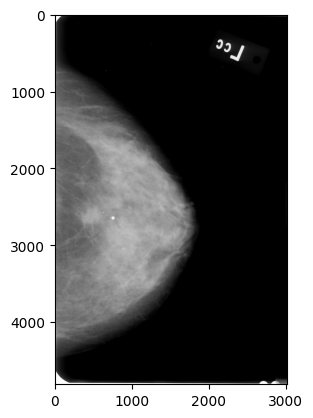

In [17]:
ct = sample.pixel_array # load the image pixel data as a numpy array
plt.figure()
plt.imshow(ct, cmap="gray")

In [9]:
image = sample.pixel_array.astype("float32")

In [10]:
image.shape

(4808, 3024)

In [11]:
image = (image - image.min()) / (image.max() - image.min())

In [12]:
image.shape

(4808, 3024)

In [13]:
image = torch.tensor(image).unsqueeze(0)

In [14]:
image.shape

torch.Size([1, 4808, 3024])

In [14]:
import pandas as pd

In [ ]:
df["count_dicoms"] = pd.NA


KeyError: 'new_col'

In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1318 entries, 0 to 1317
Data columns (total 19 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   patient_id               1318 non-null   object
 1   breast_density           1318 non-null   int64 
 2   left or right breast     1318 non-null   object
 3   image view               1318 non-null   object
 4   abnormality id           1318 non-null   int64 
 5   abnormality type         1318 non-null   object
 6   mass shape               1314 non-null   object
 7   mass margins             1275 non-null   object
 8   assessment               1318 non-null   int64 
 9   pathology                1318 non-null   object
 10  subtlety                 1318 non-null   int64 
 11  image file path          1318 non-null   object
 12  cropped image file path  1318 non-null   object
 13  ROI mask file path       1318 non-null   object
 14  Label                    1318 non-null  

In [18]:
df["count_dicoms"] = df["count_dicoms"].astype("Int64")

In [24]:
from pathlib import Path
samples_dir = Path("./data/samples")
samples_root = Path(
    "/Volumes/Samsung_T7/Not_Sync/CBIS-DDSM-All-doiJNLP-zzWs5zfZ/cbis_ddsm")
# for i, row in df.head(8).iterrows():
for i, row in df.iterrows():
    # print(f"Row {i}: folder={row['folder']}, study={row['study']}, , count_dicoms={row['count_dicoms']}")
    series_path = samples_root / row["folder"] / row["study"] / row["series"]
    # print(series_path)
    
    dicom_file = next(series_path.glob("*.dcm"), None)
    # print(dicom_file)
    # print(len(list(series_path.glob("*.dcm"))))
    number_of_dicom_files = len(list(series_path.glob("*.dcm")))
    df["count_dicoms"] = number_of_dicom_files
    # print(number_of_dicom_files)
    # print()

In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1318 entries, 0 to 1317
Data columns (total 19 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   patient_id               1318 non-null   object
 1   breast_density           1318 non-null   int64 
 2   left or right breast     1318 non-null   object
 3   image view               1318 non-null   object
 4   abnormality id           1318 non-null   int64 
 5   abnormality type         1318 non-null   object
 6   mass shape               1314 non-null   object
 7   mass margins             1275 non-null   object
 8   assessment               1318 non-null   int64 
 9   pathology                1318 non-null   object
 10  subtlety                 1318 non-null   int64 
 11  image file path          1318 non-null   object
 12  cropped image file path  1318 non-null   object
 13  ROI mask file path       1318 non-null   object
 14  Label                    1318 non-null  

In [33]:
# counted = df[df["count_dicoms"] != 1]
# print(counted)
df[df["count_dicoms"] != 1]

,patient_id,breast_density,left or right breast,image view,abnormality id,abnormality type,mass shape,mass margins,assessment,pathology,subtlety,image file path,cropped image file path,ROI mask file path,Label,folder,study,series,count_dicoms


In [30]:
(df["count_dicoms"] == 1).all()

np.True_

In [31]:
df["count_dicoms"].sum()

np.int64(1318)

In [34]:
df[df["count_dicoms"] == 1]

,patient_id,breast_density,left or right breast,image view,abnormality id,abnormality type,mass shape,mass margins,assessment,pathology,subtlety,image file path,cropped image file path,ROI mask file path,Label,folder,study,series,count_dicoms
0,P_00001,3,LEFT,CC,1,mass,IRREGULAR-ARCHITECTURAL_DISTORTION,SPICULATED,4,MALIGNANT,4,Mass-Training_P_00001_LEFT_CC/1.3.6.1.4.1.9590...,Mass-Training_P_00001_LEFT_CC_1/1.3.6.1.4.1.95...,Mass-Training_P_00001_LEFT_CC_1/1.3.6.1.4.1.95...,1,Mass-Training_P_00001_LEFT_CC,74994,24515,1
1,P_00001,3,LEFT,MLO,1,mass,IRREGULAR-ARCHITECTURAL_DISTORTION,SPICULATED,4,MALIGNANT,4,Mass-Training_P_00001_LEFT_MLO/1.3.6.1.4.1.959...,Mass-Training_P_00001_LEFT_MLO_1/1.3.6.1.4.1.9...,Mass-Training_P_00001_LEFT_MLO_1/1.3.6.1.4.1.9...,1,Mass-Training_P_00001_LEFT_MLO,90988,80834,1
2,P_00004,3,LEFT,CC,1,mass,ARCHITECTURAL_DISTORTION,ILL_DEFINED,4,BENIGN,3,Mass-Training_P_00004_LEFT_CC/1.3.6.1.4.1.9590...,Mass-Training_P_00004_LEFT_CC_1/1.3.6.1.4.1.95...,Mass-Training_P_00004_LEFT_CC_1/1.3.6.1.4.1.95...,0,Mass-Training_P_00004_LEFT_CC,95697,46540,1
3,P_00004,3,LEFT,MLO,1,mass,ARCHITECTURAL_DISTORTION,ILL_DEFINED,4,BENIGN,3,Mass-Training_P_00004_LEFT_MLO/1.3.6.1.4.1.959...,Mass-Training_P_00004_LEFT_MLO_1/1.3.6.1.4.1.9...,Mass-Training_P_00004_LEFT_MLO_1/1.3.6.1.4.1.9...,0,Mass-Training_P_00004_LEFT_MLO,20939,00162,1
4,P_00004,3,RIGHT,MLO,1,mass,OVAL,CIRCUMSCRIBED,4,BENIGN,5,Mass-Training_P_00004_RIGHT_MLO/1.3.6.1.4.1.95...,Mass-Training_P_00004_RIGHT_MLO_1/1.3.6.1.4.1....,Mass-Training_P_00004_RIGHT_MLO_1/1.3.6.1.4.1....,0,Mass-Training_P_00004_RIGHT_MLO,24486,89890,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1313,P_02033,2,RIGHT,MLO,1,mass,IRREGULAR,ILL_DEFINED,3,MALIGNANT,4,Mass-Training_P_02033_RIGHT_MLO/1.3.6.1.4.1.95...,Mass-Training_P_02033_RIGHT_MLO_1/1.3.6.1.4.1....,Mass-Training_P_02033_RIGHT_MLO_1/1.3.6.1.4.1....,1,Mass-Training_P_02033_RIGHT_MLO,37767,15389,1
1314,P_02079,2,RIGHT,CC,1,mass,ROUND,SPICULATED,3,MALIGNANT,5,Mass-Training_P_02079_RIGHT_CC/1.3.6.1.4.1.959...,Mass-Training_P_02079_RIGHT_CC_1/1.3.6.1.4.1.9...,Mass-Training_P_02079_RIGHT_CC_1/1.3.6.1.4.1.9...,1,Mass-Training_P_02079_RIGHT_CC,39196,39589,1
1315,P_02079,2,RIGHT,MLO,1,mass,ROUND,SPICULATED,3,MALIGNANT,5,Mass-Training_P_02079_RIGHT_MLO/1.3.6.1.4.1.95...,Mass-Training_P_02079_RIGHT_MLO_1/1.3.6.1.4.1....,Mass-Training_P_02079_RIGHT_MLO_1/1.3.6.1.4.1....,1,Mass-Training_P_02079_RIGHT_MLO,29838,90663,1
1316,P_02092,2,LEFT,CC,1,mass,IRREGULAR,SPICULATED,3,MALIGNANT,2,Mass-Training_P_02092_LEFT_CC/1.3.6.1.4.1.9590...,Mass-Training_P_02092_LEFT_CC_1/1.3.6.1.4.1.95...,Mass-Training_P_02092_LEFT_CC_1/1.3.6.1.4.1.95...,1,Mass-Training_P_02092_LEFT_CC,80250,67422,1


In [35]:
df["count_dicoms"].isna().sum()

np.int64(0)

In [36]:
(df["count_dicoms"].eq(1).all() and df["count_dicoms"].notna().all() and df["count_dicoms"].sum() == len(df))

np.True_

In [38]:
not_one = df[df["count_dicoms"] != 1]
print(not_one)

Empty DataFrame
Columns: [patient_id, breast_density, left or right breast, image view, abnormality id, abnormality type, mass shape, mass margins, assessment, pathology, subtlety, image file path, cropped image file path, ROI mask file path, Label, folder, study, series, count_dicoms]
Index: []


In [40]:
all_one = (df["count_dicoms"] == 1).all()
print("All count_dicoms are 1:", all_one)

All count_dicoms are 1: True


In [41]:
df[df["count_dicoms"] != 1].shape[0]

0